# 🔆 Overview
This notebook imports minute level synthetic data *train_onset_final_0329.csv* and *test_onset_final_0329.csv*, builds the logistic regression model with Leave-One-Dog-Out Cross Validation.

Here, we predict the glucose status of current using x minutes data that n-minute ahead of now.

# 🔆 Setup / Import Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    ConfusionMatrixDisplay
)

In [2]:
# mounting on gdrive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# import data
# WooJung
# data_path = "/content/drive/MyDrive/UC_Berkeley/DATASCI 210/210 Capstone/data_0228"

# Ainsley


# Ci
data_path = "/content/drive/MyDrive/210 Capstone/final_data/updated"

Based on the EDA, Canine 1 has more completed cases for both Hyper and Hypo and we want to use Canine 1 as the test set; and Canine 2-5 as the train set to run the LODO cross validation.

In [4]:
# import train df: canine 2 - 6
file_train_df = os.path.join(data_path, "train_onset_final_0329.csv")
raw_train_df = pd.read_csv(file_train_df)

raw_train_df.head()

,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,split
0,canine2,canine2-001,2025-04-09 12:56:00,308.000000,hyperglycemia,True,True,False,False,train
1,canine2,canine2-001,2025-04-09 12:57:00,305.615730,hyperglycemia,True,False,False,False,train
2,canine2,canine2-001,2025-04-09 12:58:00,303.471173,hyperglycemia,True,False,False,False,train
3,canine2,canine2-001,2025-04-09 12:59:00,301.876377,hyperglycemia,True,False,False,False,train
4,canine2,canine2-001,2025-04-09 13:00:00,298.388740,hyperglycemia,True,False,False,False,train


In [5]:
# import test df: canine 1
file_test_df = os.path.join(data_path, "test_onset_final_0329.csv")
raw_test_df = pd.read_csv(file_test_df)
raw_test_df.head()

,dogID,ID,timestamp,glucose,glucose_category,unsafe,observed,onset,onset_observed,split
0,canine1,canine1-001,2025-11-01 05:51:00,375.000000,hyperglycemia,True,True,False,False,test
1,canine1,canine1-001,2025-11-01 05:52:00,375.056846,hyperglycemia,True,False,False,False,test
2,canine1,canine1-001,2025-11-01 05:53:00,374.714980,hyperglycemia,True,False,False,False,test
3,canine1,canine1-001,2025-11-01 05:54:00,375.045685,hyperglycemia,True,False,False,False,test
4,canine1,canine1-001,2025-11-01 05:55:00,375.676269,hyperglycemia,True,False,False,False,test


In [41]:
print("In Train Set:")
print(raw_train_df['dogID'].value_counts().to_string())
print("In Test Set:")
print(raw_test_df['dogID'].value_counts().to_string())

In Train Set:
dogID
canine6    178346
canine5     70271
canine3     62608
canine4     32281
canine2     13227
In Test Set:
dogID
canine1    36618


# 🔆 Feature Engineering

Next we're going to build engineered features from a historical window that ends `ahead_minutes` before the target time:

history_minutes=30, ahead_minutes=15

-> use [t-45, t-15) to predict target at t

In [1]:
def feature_engineering_minute_ahead(
    df,
    history_minutes=30,
    ahead_minutes=15,
    glucose_col="glucose",
    target_col="unsafe",
    onset_col="onset",
    dog_col="dogID",
    segment_col="ID",
    time_col="timestamp"
):
    """
    Build engineered features from minute-level synthetic data.

    For each target time t:
      - use a history window of length `history_minutes`
      - the history window ends `ahead_minutes` before t
      - predict target_col at time t

    Example:
      history_minutes = 30, ahead_minutes = 10
      -> use [t-40, t-10) to predict status at t
    """

    features = []

    # Group by ID so each window stays inside the subset
    for seg_id, group in df.groupby(segment_col, sort=False):
        dog = group[dog_col].iloc[0]

        # Convert needed columns to NumPy arrays for faster slicing
        glucose = group[glucose_col].astype(float).to_numpy()
        timestamps = pd.to_datetime(group[time_col]).to_numpy()
        targets = group[target_col].astype(int).to_numpy()
        onset_values = group[onset_col].astype(bool).to_numpy()

        n = len(group)

        # Earliest valid target index:
        # we need enough earlier rows to cover both history and ahead gap
        start_i = history_minutes + ahead_minutes

        for i in range(start_i, n):
            # Window layout:
            #   target row = i
            #   history ends at i - ahead_minutes (exclusive)
            hist_end = i - ahead_minutes
            hist_start = hist_end - history_minutes

            # Slice the glucose history window and its timestamps
            g = glucose[hist_start:hist_end]
            ts_window = timestamps[hist_start:hist_end]

            # Require a full history window
            if len(g) < history_minutes:
                continue

            # Summary statistics from the history window
            min_glucose = np.min(g)
            max_glucose = np.max(g)
            first_glucose = g[0]
            last_glucose = g[-1]

            # Unweighted mean of glucose values
            mean_glucose = np.mean(g)

            # Slope feature:
            # overall change across the window, scaled by history_minutes
            slope = (last_glucose - first_glucose) / history_minutes

            # Mean gap between consecutive timestamps in the history window
            # This should be 1 for minute-level synthetic data
            mean_gap = 1.0 # np.diff(ts_window) / np.timedelta64(1, "m")

            # Number of readings used in this history window
            num_readings = len(g)

            # Store one feature row for this target time t
            features.append({
                segment_col: seg_id,          # subset ID / continuous segment
                dog_col: dog,                 # dog identifier for LODO later
                time_col: timestamps[i],      # target time t

                "history_minutes": history_minutes,
                "ahead_minutes": ahead_minutes,

                "mean_glucose": mean_glucose,
                "min_glucose": min_glucose,
                "max_glucose": max_glucose,
                "slope": slope,
                "last_glucose": last_glucose,
                "mean_gap": mean_gap,
                "num_readings": num_readings,

                # target at time t
                target_col: targets[i],
                onset_col: onset_values[i]
            })

    return pd.DataFrame(features)

In [51]:
# Build one feature table for one setting
train_feat_df = feature_engineering_minute_ahead(
    df=raw_train_df,
    history_minutes=30,
    ahead_minutes=15
)

test_feat_df = feature_engineering_minute_ahead(
    df=raw_test_df,
    history_minutes=30,
    ahead_minutes=15
)

In [52]:
train_feat_df.head()

,ID,dogID,timestamp,history_minutes,ahead_minutes,mean_glucose,min_glucose,max_glucose,slope,last_glucose,mean_gap,num_readings,unsafe,onset
0,canine2-001,canine2,2025-04-09 13:41:00,30,15,280.147356,264.476275,308.000000,-1.450791,264.476275,1.0,30,1,False
1,canine2-001,canine2,2025-04-09 13:42:00,30,15,278.680689,264.000000,305.615730,-1.387191,264.000000,1.0,30,1,False
2,canine2-001,canine2,2025-04-09 13:43:00,30,15,277.287060,263.806835,303.471173,-1.322145,263.806835,1.0,30,1,False
3,canine2-001,canine2,2025-04-09 13:44:00,30,15,275.984008,263.806835,301.876377,-1.249891,264.379635,1.0,30,1,False
4,canine2-001,canine2,2025-04-09 13:45:00,30,15,274.746620,263.806835,298.388740,-1.121133,264.754736,1.0,30,1,False


In [53]:
test_feat_df.head()

,ID,dogID,timestamp,history_minutes,ahead_minutes,mean_glucose,min_glucose,max_glucose,slope,last_glucose,mean_gap,num_readings,unsafe,onset
0,canine1-001,canine1,2025-11-01 06:36:00,30,15,374.192531,373.098884,375.676269,-0.059466,373.216021,1.0,30,1,False
1,canine1-001,canine1,2025-11-01 06:37:00,30,15,374.125865,373.000000,375.676269,-0.068562,373.000000,1.0,30,1,False
2,canine1-001,canine1,2025-11-01 06:38:00,30,15,374.064314,373.000000,375.676269,-0.050155,373.210330,1.0,30,1,False
3,canine1-001,canine1,2025-11-01 06:39:00,30,15,374.025546,373.000000,375.676269,-0.049792,373.551931,1.0,30,1,False
4,canine1-001,canine1,2025-11-01 06:40:00,30,15,374.020021,373.000000,375.676269,-0.026545,374.879921,1.0,30,1,False


Sanity Check

In [54]:
# check 'mean_gap' should be 1
print(train_feat_df['mean_gap'].describe())
print(test_feat_df['mean_gap'].describe())


count    344763.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: mean_gap, dtype: float64
count    35673.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: mean_gap, dtype: float64


In [11]:
# Timestamp comparison after applying the lookback window
# feat_df_min_timestamp should be "history_minutes+ahead_minutes" after the df_min_timestamp

# Get min/max timestamps from df
df_time_summary = raw_train_df.groupby('ID')['timestamp'].agg(['min', 'max']).rename(columns={'min': 'df_min_timestamp', 'max': 'df_max_timestamp'})

# Get min/max timestamps from feat_df
feat_df_time_summary = train_feat_df.groupby('ID')['timestamp'].agg(['min', 'max']).rename(columns={'min': 'feat_df_min_timestamp', 'max': 'feat_df_max_timestamp'})

# Merge the summaries for comparison
comparison_df = pd.merge(df_time_summary, feat_df_time_summary, on='ID', how='outer')

print("Min/Max Timestamps Comparison by ID:")
print(comparison_df.to_string())

Min/Max Timestamps Comparison by ID:
                df_min_timestamp     df_max_timestamp feat_df_min_timestamp feat_df_max_timestamp
ID                                                                                               
canine2-001  2025-04-09 12:56:00  2025-04-10 23:58:00   2025-04-09 13:41:00   2025-04-10 23:58:00
canine2-002  2025-04-11 00:58:00  2025-04-11 22:17:00   2025-04-11 01:43:00   2025-04-11 22:17:00
canine2-003  2025-04-12 00:31:00  2025-04-12 11:03:00   2025-04-12 01:16:00   2025-04-12 11:03:00
canine2-004  2025-04-12 13:49:00  2025-04-13 23:36:00   2025-04-12 14:34:00   2025-04-13 23:36:00
canine2-005  2025-04-14 00:36:00  2025-04-14 11:33:00   2025-04-14 01:21:00   2025-04-14 11:33:00
canine2-006  2025-04-14 23:08:00  2025-04-16 08:43:00   2025-04-14 23:53:00   2025-04-16 08:43:00
canine2-007  2025-04-16 10:42:00  2025-04-19 08:18:00   2025-04-16 11:27:00   2025-04-19 08:18:00
canine2-008  2025-04-19 13:03:00  2025-04-19 18:34:00   2025-04-19 13:48:00   202

#🔆 Logistic Regression
Binary Logistic Regression model with Leave-One-Dog-Out

## ⭐ Model Train

In [67]:
def run_lodo_logistic_regression(
    train_df,
    feature_cols,
    target_col="unsafe",
    group_col="dogID",
    threshold=0.5,
    class_weight="balanced",
    random_state=42,
    max_iter=2000
):
    """
    Run Leave-One-Dog-Out logistic regression.

    Returns:
    - fold_df: metrics for each held-out dog
    - overall: average of fold-level metrics so each dog has equal weight
    """
    model_df = train_df.copy()

    X = model_df[feature_cols]
    y = model_df[target_col].astype(int)
    groups = model_df[group_col]

    logo = LeaveOneGroupOut()

    # Simple pipeline: scale, then fit logistic regression
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=max_iter, class_weight=class_weight, random_state=random_state))
    ])

    fold_results = []

    # Hold out one dog each time
    for train_idx, val_idx in logo.split(X, y, groups):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        val_dog = groups.iloc[val_idx].iloc[0]

        model.fit(X_train, y_train)

        # Probability of unsafe_now = 1
        y_prob = model.predict_proba(X_val)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

        # Calculate accuracy for onset==True cases
        onset_val = model_df.iloc[val_idx]['onset'].astype(bool)
        y_val_onset = y_val[onset_val]
        y_pred_onset = y_pred[onset_val]
        onset_accuracy = accuracy_score(y_val_onset, y_pred_onset)

        fold_results.append({
            "val_dog": val_dog,
            "n_val": len(y_val),
            "accuracy": accuracy_score(y_val, y_pred),
            "precision": precision_score(y_val, y_pred, zero_division=0),
            "recall": recall_score(y_val, y_pred, zero_division=0),
            "f1": f1_score(y_val, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_val, y_prob),
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
            "onset_accuracy": onset_accuracy
        })

    fold_df = pd.DataFrame(fold_results)

    overall = {
        "accuracy": fold_df["accuracy"].mean(),
        "precision": fold_df["precision"].mean(),
        "recall": fold_df["recall"].mean(),
        "f1": fold_df["f1"].mean(),
        "roc_auc": fold_df["roc_auc"].mean(),
        "onset_accuracy": fold_df["onset_accuracy"].mean()
    }

    return fold_df, overall

In [87]:
feature_cols = [
    "mean_glucose",
    "min_glucose",
    "max_glucose",
    "slope",
    "last_glucose",
]

fold_df, overall = run_lodo_logistic_regression(
    train_df=train_feat_df,
    feature_cols=feature_cols,
    target_col="unsafe",
    group_col="dogID",
    threshold=0.5
)

print("=================================================")
print("LODO Logistic Regression Result By Fold:")
print("=================================================")
display(fold_df)
print("=================================================")
print("LODO Logistic Regression Overall Result:")
print("=================================================")
print(f"Accuracy : {overall['accuracy']:.3f}")
print(f"Precision: {overall['precision']:.3f}")
print(f"Recall   : {overall['recall']:.3f}")
print(f"F1       : {overall['f1']:.3f}")
print(f"ROC-AUC  : {overall['roc_auc']:.3f}")
print(f"Onset_Acc: {overall['onset_accuracy']:.3f}")

LODO Logistic Regression Result By Fold:


,val_dog,n_val,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp,onset_accuracy
0,canine2,12867,0.923525,0.966781,0.823554,0.889438,0.895681,7925,136,848,3958,0.057692
1,canine3,60538,0.976659,0.991265,0.976440,0.983797,0.996959,16229,378,1035,42896,0.136364
2,canine4,31471,0.968415,0.967089,0.850288,0.904935,0.994616,25746,161,833,4731,0.074074
3,canine5,69461,0.976548,0.992037,0.978771,0.985360,0.995538,13013,440,1189,54819,0.107527
4,canine6,170426,0.965070,0.990313,0.959069,0.974441,0.991620,50994,1110,4843,113479,0.087349


LODO Logistic Regression Overall Result:
Accuracy : 0.962
Precision: 0.981
Recall   : 0.918
F1       : 0.948
ROC-AUC  : 0.975
Onset_Acc: 0.093


###🔆 Onsite Accuracy
We also want to specifically look at the prediction accuracies on onset cases:

In [60]:
def run_lodo_logistic_regression_onsite(
    train_feat_df,
    feature_cols,
    threshold,
    raw_train_df
):
    """
    Runs the Leave-One-Dog-Out (LODO) cross-validation process to capture fold-level predictions.

    Returns:
        pd.DataFrame: A DataFrame with LODO predictions and onset information per fold.
    """

    # Prepare data for LODO
    X = train_feat_df[feature_cols]
    y = train_feat_df["unsafe"].astype(int)
    groups = train_feat_df["dogID"]

    logo = LeaveOneGroupOut()

    # Initialize a list to store predictions for all validation folds
    all_lodo_predictions = []

    # Define the model pipeline
    model_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
    ])

    # Iterate through each LODO split
    for train_idx, val_idx in logo.split(X, y, groups):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Fit the model on the training data for the current fold
        model_pipeline.fit(X_train, y_train)

        # Get the validation dogID for this fold
        val_dog_id = groups.iloc[val_idx].iloc[0]

        # --- Predictions for Validation Set ---
        y_prob_val = model_pipeline.predict_proba(X_val)[:, 1]
        y_pred_val = (y_prob_val >= threshold).astype(int)

        current_val_df = train_feat_df.iloc[val_idx][['dogID', 'ID', 'timestamp', 'unsafe']].copy()
        current_val_df['unsafe_predict'] = y_pred_val
        current_val_df['val_dog'] = val_dog_id
        current_val_df['train_val'] = 'val'
        all_lodo_predictions.append(current_val_df)

        # --- Predictions for Training Set ---
        y_prob_train = model_pipeline.predict_proba(X_train)[:, 1]
        y_pred_train = (y_prob_train >= threshold).astype(int)

        current_train_df = train_feat_df.iloc[train_idx][['dogID', 'ID', 'timestamp', 'unsafe']].copy()
        current_train_df['unsafe_predict'] = y_pred_train
        current_train_df['val_dog'] = val_dog_id # The training set is everything EXCEPT this dog_id
        current_train_df['train_val'] = 'train'
        all_lodo_predictions.append(current_train_df)

    # Concatenate all fold predictions into a single DataFrame
    combined_lodo_preds = pd.concat(all_lodo_predictions, ignore_index=True)

    # Ensure 'timestamp' columns are datetime objects for merging
    # It's better to convert only once after concat if raw_train_df is large
    raw_train_df['timestamp'] = pd.to_datetime(raw_train_df['timestamp'])
    combined_lodo_preds['timestamp'] = pd.to_datetime(combined_lodo_preds['timestamp'])

    # Merge with raw_train_df to get the 'onset' column
    final_lodo_output_df = pd.merge(
        combined_lodo_preds,
        raw_train_df[['ID', 'timestamp', 'onset']],
        on=['ID', 'timestamp'],
        how='left'
    )

    return final_lodo_output_df

In [61]:
final_lodo_output_df = run_lodo_logistic_regression_onsite(
    train_feat_df=train_feat_df,
    feature_cols=feature_cols,
    threshold=0.5,
    raw_train_df=raw_train_df
)

display(final_lodo_output_df.head(100))

print(f"\nTotal rows in the combined LODO predictions: {len(final_lodo_output_df)}")


DataFrame with LODO predictions and onset information per fold (head):


,dogID,ID,timestamp,unsafe,unsafe_predict,val_dog,train_val,onset
0,canine2,canine2-001,2025-04-09 13:41:00,1,1,canine2,val,False
1,canine2,canine2-001,2025-04-09 13:42:00,1,1,canine2,val,False
2,canine2,canine2-001,2025-04-09 13:43:00,1,1,canine2,val,False
3,canine2,canine2-001,2025-04-09 13:44:00,1,1,canine2,val,False
4,canine2,canine2-001,2025-04-09 13:45:00,1,1,canine2,val,False
...,...,...,...,...,...,...,...,...
95,canine2,canine2-001,2025-04-09 15:16:00,0,0,canine2,val,False
96,canine2,canine2-001,2025-04-09 15:17:00,0,0,canine2,val,False
97,canine2,canine2-001,2025-04-09 15:18:00,0,0,canine2,val,False
98,canine2,canine2-001,2025-04-09 15:19:00,0,0,canine2,val,False



Total rows in the combined LODO predictions: 1723815


In [64]:
# Filter for onset == True cases
onset_true_df = final_lodo_output_df[final_lodo_output_df['onset'] == True]
onset_true_df.head()

,dogID,ID,timestamp,unsafe,unsafe_predict,val_dog,train_val,onset
160,canine2,canine2-001,2025-04-09 16:21:00,1,0,canine2,val,True
331,canine2,canine2-001,2025-04-09 19:12:00,1,0,canine2,val,True
418,canine2,canine2-001,2025-04-09 20:39:00,1,0,canine2,val,True
478,canine2,canine2-001,2025-04-09 21:39:00,1,0,canine2,val,True
525,canine2,canine2-001,2025-04-09 22:26:00,1,0,canine2,val,True


In [63]:
# Group by fold and train_val
summary_onset_df = onset_true_df.groupby(['val_dog', 'train_val']).agg(
    correct_unsafe_predictions=('unsafe_predict', lambda x: (x == onset_true_df.loc[x.index, 'unsafe']).sum()),
    total_unsafe_predictions=('unsafe_predict', 'count')
).reset_index()

# Calculate the accuracy specifically for onset=True cases
summary_onset_df['accuracy_unsafe_predict'] = summary_onset_df['correct_unsafe_predictions'] / summary_onset_df['total_unsafe_predictions']

# Pivot the table to show train and val accuracies for each dog
pivoted_accuracy_df = summary_onset_df.pivot_table(
    index='val_dog',
    columns='train_val',
    values='accuracy_unsafe_predict'
).reset_index()

# Rename columns for clarity
pivoted_accuracy_df.rename(columns={
    'train': 'accuracy_train',
    'val': 'accuracy_val'
}, inplace=True)

# Remove the 'train_val' label from the column header
pivoted_accuracy_df.columns.name = None

print("Accuracy Summary for Onset=True Cases:")
display(pivoted_accuracy_df)

Accuracy Summary for Onset=True Cases:


,val_dog,accuracy_train,accuracy_val
0,canine2,0.098765,0.057692
1,canine3,0.099812,0.136364
2,canine4,0.069027,0.074074
3,canine5,0.108365,0.107527
4,canine6,0.090592,0.087349


## ⭐ Tune Thresholds

Next, we tested different thresholds and comparing the results and see if we can further decrease the FN:

In [15]:
# Tune the thresholds from 0.1 - 0.9

thresholds = np.arange(0.1, 1.0, 0.1)
lodo_tuning_results = []

# run the lodo logistic regression for different thresholds
for ts in thresholds:
    _, overall_metrics = run_lodo_logistic_regression(
        train_df=train_feat_df,
        feature_cols=feature_cols,
        threshold=ts
    )
    overall_metrics['threshold'] = ts
    lodo_tuning_results.append(overall_metrics)

# output the results by threshold
tuning_df = pd.DataFrame(lodo_tuning_results)
tuning_df = tuning_df.round(3)
tuning_df.sort_values(["accuracy", "recall"], ascending=[False, False])

,accuracy,precision,recall,f1,roc_auc,threshold
3,0.964,0.966,0.939,0.952,0.975,0.4
4,0.962,0.981,0.918,0.948,0.975,0.5
2,0.960,0.941,0.955,0.947,0.975,0.3
5,0.955,0.988,0.890,0.935,0.975,0.6
1,0.948,0.902,0.968,0.932,0.975,0.2
6,0.943,0.994,0.852,0.913,0.975,0.7
7,0.927,0.996,0.805,0.883,0.975,0.8
0,0.923,0.847,0.975,0.902,0.975,0.1
8,0.901,0.998,0.735,0.828,0.975,0.9


## ⭐ Model Test

From the tuning results, we see threshold = 0.4 has the highest accuracy and relatively high recall.

Next, we'll fit the model on canine1 and set the threshold as 0.4.

In [73]:
def fit_and_predict_test(
    train_df,
    test_df,
    feature_cols,
    target_col="unsafe",
    threshold=0.4,  # chosen threshold
    class_weight="balanced",
    random_state=42,
    max_iter=2000
):
    """
    Fit logistic regression on the full training set (canine2-6),
    then predict and evaluate on the separate test set (canine1).
    """

    train_model_df = train_df.copy()
    test_model_df  = test_df.copy()

    X_train = train_model_df[feature_cols]
    y_train = train_model_df[target_col].astype(int)

    X_test = test_model_df[feature_cols]
    y_test = test_model_df[target_col].astype(int)

    # Same model pipeline as before
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight=class_weight, random_state=random_state))
    ])

    # Fit on training dogs
    model.fit(X_train, y_train)

    # Predict on held-out test dog
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Calculate accuracy for onset==True cases for the test set
    onset_test = test_model_df['onset'].astype(bool)
    y_test_onset = y_test[onset_test]
    y_pred_onset = y_pred[onset_test]

    onset_accuracy = accuracy_score(y_test_onset, y_pred_onset)

    test_results = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "onset_accuracy": onset_accuracy
    }

    # Save predictions back to the test rows
    pred_df = test_model_df.copy()
    pred_df["y_prob"] = y_prob
    pred_df["y_pred"] = y_pred

    return model, test_results, pred_df

In [74]:
# fit final model to test on canine1
model, test_results, pred_df = fit_and_predict_test(
    train_df=train_feat_df,
    test_df=test_feat_df,
    feature_cols=feature_cols,
    target_col="unsafe",
    threshold=0.4 # chosen threshold
)

print("Held-out test results:")
test_results_df = pd.DataFrame([test_results]).round(3)
test_results_df

Held-out test results:


,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp,onset_accuracy
0,0.935,0.979,0.922,0.949,0.94,11705,464,1845,21659,0.135


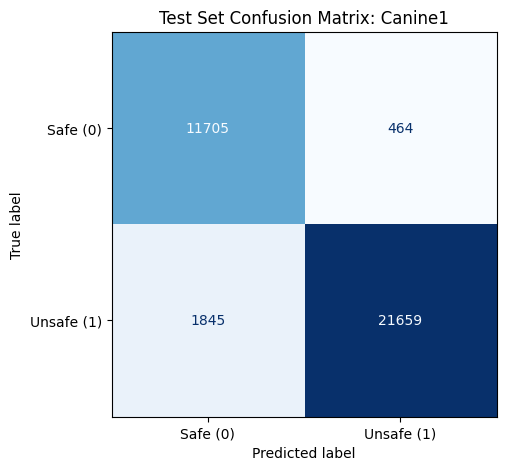

In [75]:
# Plot the Confusion Matrix for Test Set
cm = confusion_matrix(pred_df["unsafe"], pred_df["y_pred"])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Safe (0)", "Unsafe (1)"]
)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Test Set Confusion Matrix: Canine1")
plt.show()

#🔆 Shift Time Window

We shift the feature window farther back in time to test how much predictive signal remains in older glucose history. By varying both the **amount of past data** used and **how far** that data is from the target time, we can evaluate how early the model can still predict a dog’s current unsafe status and identify the practical limit of early warning.

In [76]:
def evaluate_history_ahead_grid_lodo(
    raw_train_df,
    history_grid,
    ahead_grid,
    feature_cols,
    glucose_col="glucose",
    target_col="unsafe",
    dog_col="dogID",
    segment_col="ID",
    time_col="timestamp",
    threshold=0.5
):
    """
    Use only the training dogs to compare different history/ahead settings.

    For each (history_minutes, ahead_minutes):
      1) build engineered features from raw training data
      2) run Leave-One-Dog-Out logistic regression on the training dogs
      3) save the average fold-level metrics

    Returns:
      results_df: one row per setting, for model selection
    """

    results = []

    for history_minutes in history_grid:
        for ahead_minutes in ahead_grid:
            print(f"Running LODO for history={history_minutes}, ahead={ahead_minutes}")

            # Build features from raw training data for this setting
            train_feat_df = feature_engineering_minute_ahead(
                df=raw_train_df,
                history_minutes=history_minutes,
                ahead_minutes=ahead_minutes,
                glucose_col=glucose_col,
                target_col=target_col,
                dog_col=dog_col,
                segment_col=segment_col,
                time_col=time_col
            )


            # Run LODO on the training dogs only
            fold_df, overall = run_lodo_logistic_regression(
                train_df=train_feat_df,
                feature_cols=feature_cols,
                target_col=target_col,
                group_col=dog_col,
                threshold=threshold
            )

            # Save summary metrics for this setting
            results.append({
                "history_minutes": history_minutes,
                "ahead_minutes": ahead_minutes,
                "n_samples": len(train_feat_df),
                "accuracy": overall["accuracy"],
                "precision": overall["precision"],
                "recall": overall["recall"],
                "f1": overall["f1"],
                "roc_auc": overall["roc_auc"]
            })

    results_df = pd.DataFrame(results)
    return results_df

In [77]:
history_grid = [10, 30, 45]
ahead_grid = [15, 30, 45]

feature_cols = [
    "mean_glucose",
    "min_glucose",
    "max_glucose",
    "slope",
    "last_glucose",
]

lodo_results_df = evaluate_history_ahead_grid_lodo(
    raw_train_df=raw_train_df,
    history_grid=history_grid,
    ahead_grid=ahead_grid,
    feature_cols=feature_cols,
    threshold=0.5
)

lodo_results_df = lodo_results_df.round(3)
lodo_results_df.sort_values(["recall", "f1"], ascending=[False, False])

Running LODO for history=10, ahead=15
Running LODO for history=10, ahead=30
Running LODO for history=10, ahead=45
Running LODO for history=30, ahead=15
Running LODO for history=30, ahead=30
Running LODO for history=30, ahead=45
Running LODO for history=45, ahead=15
Running LODO for history=45, ahead=30
Running LODO for history=45, ahead=45


,history_minutes,ahead_minutes,n_samples,accuracy,precision,recall,f1,roc_auc
0,10,15,350083,0.962,0.982,0.918,0.948,0.975
3,30,15,344763,0.962,0.981,0.918,0.948,0.975
6,45,15,340773,0.961,0.979,0.916,0.946,0.974
4,30,30,340773,0.934,0.951,0.871,0.908,0.965
1,10,30,346093,0.934,0.953,0.870,0.908,0.965
7,45,30,336783,0.933,0.949,0.870,0.907,0.964
5,30,45,336783,0.910,0.928,0.829,0.874,0.950
8,45,45,332793,0.910,0.927,0.829,0.874,0.949
2,10,45,342103,0.910,0.929,0.827,0.873,0.951


In [59]:
# Choose the BEST window and fit the canine 1
best_history = 10
best_ahead = 15

train_feat_df = feature_engineering_minute_ahead(
    df=raw_train_df,
    history_minutes=best_history,
    ahead_minutes=best_ahead
)

test_feat_df = feature_engineering_minute_ahead(
    df=raw_test_df,
    history_minutes=best_history,
    ahead_minutes=best_ahead
)

model, test_results, pred_df = fit_and_predict_test(
    train_df=train_feat_df,
    test_df=test_feat_df,
    feature_cols=feature_cols,
    target_col="unsafe",
    threshold=0.4
)

pd.DataFrame([test_results]).round(3)

,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,0.935,0.979,0.921,0.949,0.94,11890,459,1883,21861


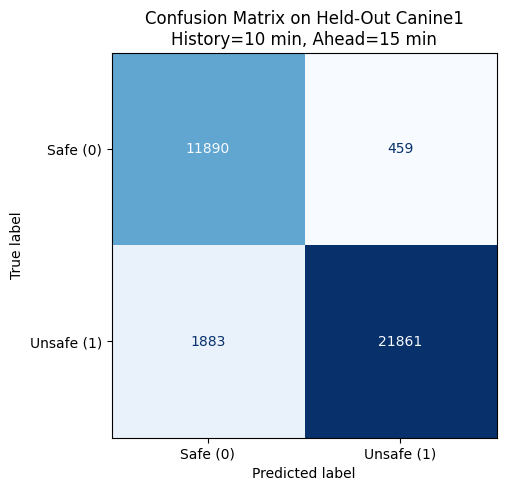

In [60]:
# Plot the Confusion Matrix
cm = confusion_matrix(pred_df["unsafe"], pred_df["y_pred"])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Safe (0)", "Unsafe (1)"]
)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(
    f"Confusion Matrix on Held-Out Canine1\n"
    f"History={best_history} min, Ahead={best_ahead} min"
)
plt.show()